# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Sri Lanka Flood District Dataset](https://www.kaggle.com/datasets/rasindupramith/sri-lanka-district-climate-and-flood-risk20152024)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('sri_lanka_flood_risk_modeled.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,date,precipitation_sum,rain_sum,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean,temperature_2m_max,wind_speed_10m_max,district,latitude,longitude,province,climatic_zone,rain_24h,rain_48h,rain_72h,soil_saturation_index,year,flood_risk_score,flood_category
0,2015-01-01,1.6,1.6,0.375,0.378,29.1,8.2,Ampara,7.2912,81.6724,Eastern,Dry,1.6,1.6,1.6,0.3762,2015,0.2,Low Risk (Normal)
1,2015-01-02,1.3,1.3,0.372,0.373,28.9,7.9,Ampara,7.2912,81.6724,Eastern,Dry,1.3,2.9,2.9,0.3724,2015,0.3,Low Risk (Normal)
2,2015-01-03,0.0,0.0,0.361,0.368,29.4,11.4,Ampara,7.2912,81.6724,Eastern,Dry,0.0,1.3,2.9,0.3638,2015,0.3,Low Risk (Normal)
3,2015-01-04,0.2,0.2,0.349,0.360,29.1,13.9,Ampara,7.2912,81.6724,Eastern,Dry,0.2,0.2,1.5,0.3534,2015,0.1,Low Risk (Normal)
4,2015-01-05,3.3,3.3,0.349,0.353,27.8,16.5,Ampara,7.2912,81.6724,Eastern,Dry,3.3,3.5,3.5,0.3506,2015,0.3,Low Risk (Normal)


## last Five row

In [4]:
df.tail()

,date,precipitation_sum,rain_sum,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean,temperature_2m_max,wind_speed_10m_max,district,latitude,longitude,province,climatic_zone,rain_24h,rain_48h,rain_72h,soil_saturation_index,year,flood_risk_score,flood_category
91320,2024-12-27,8.2,8.2,0.242,0.256,28.3,17.4,Vavuniya,8.7542,80.4982,Northern,Dry,8.2,8.4,9.0,0.2476,2024,0.8,Low Risk (Normal)
91321,2024-12-28,0.4,0.4,0.282,0.250,28.8,18.4,Vavuniya,8.7542,80.4982,Northern,Dry,0.4,8.6,8.8,0.2692,2024,0.8,Low Risk (Normal)
91322,2024-12-29,1.6,1.6,0.269,0.247,29.1,20.0,Vavuniya,8.7542,80.4982,Northern,Dry,1.6,2.0,10.2,0.2602,2024,0.9,Low Risk (Normal)
91323,2024-12-30,6.3,6.3,0.291,0.248,28.3,19.2,Vavuniya,8.7542,80.4982,Northern,Dry,6.3,7.9,8.3,0.2738,2024,0.8,Low Risk (Normal)
91324,2024-12-31,14.0,14.0,0.384,0.280,26.0,23.4,Vavuniya,8.7542,80.4982,Northern,Dry,14.0,20.3,21.9,0.3424,2024,2.0,Low Risk (Normal)


## Shape of our dataset

In [5]:
df.shape

(91325, 19)

## List out all columns

In [6]:
df.columns

Index(['date', 'precipitation_sum', 'rain_sum', 'soil_moisture_0_to_7cm_mean',
       'soil_moisture_7_to_28cm_mean', 'temperature_2m_max',
       'wind_speed_10m_max', 'district', 'latitude', 'longitude', 'province',
       'climatic_zone', 'rain_24h', 'rain_48h', 'rain_72h',
       'soil_saturation_index', 'year', 'flood_risk_score', 'flood_category'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

date                             object
precipitation_sum               float64
rain_sum                        float64
soil_moisture_0_to_7cm_mean     float64
soil_moisture_7_to_28cm_mean    float64
temperature_2m_max              float64
wind_speed_10m_max              float64
district                         object
latitude                        float64
longitude                       float64
province                         object
climatic_zone                    object
rain_24h                        float64
rain_48h                        float64
rain_72h                        float64
soil_saturation_index           float64
year                              int64
flood_risk_score                float64
flood_category                   object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91325 entries, 0 to 91324
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          91325 non-null  object 
 1   precipitation_sum             91325 non-null  float64
 2   rain_sum                      91325 non-null  float64
 3   soil_moisture_0_to_7cm_mean   91325 non-null  float64
 4   soil_moisture_7_to_28cm_mean  91325 non-null  float64
 5   temperature_2m_max            91325 non-null  float64
 6   wind_speed_10m_max            91325 non-null  float64
 7   district                      91325 non-null  object 
 8   latitude                      91325 non-null  float64
 9   longitude                     91325 non-null  float64
 10  province                      91325 non-null  object 
 11  climatic_zone                 91325 non-null  object 
 12  rain_24h                      91325 non-null  float64
 13  r

## Check Null Value

In [9]:
df.isnull().sum()

date                            0
precipitation_sum               0
rain_sum                        0
soil_moisture_0_to_7cm_mean     0
soil_moisture_7_to_28cm_mean    0
temperature_2m_max              0
wind_speed_10m_max              0
district                        0
latitude                        0
longitude                       0
province                        0
climatic_zone                   0
rain_24h                        0
rain_48h                        0
rain_72h                        0
soil_saturation_index           0
year                            0
flood_risk_score                0
flood_category                  0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,precipitation_sum,rain_sum,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean,temperature_2m_max,wind_speed_10m_max,latitude,longitude,rain_24h,rain_48h,rain_72h,soil_saturation_index,year,flood_risk_score
count,91325.000000,91325.000000,91325.000000,91325.000000,91325.000000,91325.000000,91325.000000,91325.000000,91325.000000,91325.000000,91325.000000,91325.000000,91325.000000,91325.000000
mean,5.546671,5.546671,0.332286,0.327313,29.900777,17.156757,7.588212,80.587948,5.546671,11.089380,16.628645,0.330297,2019.500411,4.417119
std,10.224598,10.224598,0.126538,0.120991,3.253310,6.948491,1.033023,0.533065,10.224598,17.677075,24.253368,0.122669,2.872678,10.690699
min,0.000000,0.000000,0.011000,0.017000,14.700000,2.500000,5.954900,79.839400,0.000000,0.000000,0.000000,0.034400,2015.000000,0.000000
25%,0.200000,0.200000,0.233000,0.223000,28.400000,12.100000,6.927100,80.221000,0.200000,0.900000,1.800000,0.230000,2017.000000,0.200000
50%,1.800000,1.800000,0.350000,0.334000,29.800000,16.200000,7.291200,80.498200,1.800000,4.600000,7.800000,0.343200,2020.000000,0.700000
75%,6.700000,6.700000,0.443000,0.430000,31.700000,21.000000,8.311400,81.018800,6.700000,14.600000,22.500000,0.435200,2022.000000,1.900000
max,321.800000,321.800000,0.518000,0.518000,40.400000,76.000000,9.661500,81.674700,321.800000,481.500000,544.100000,0.518000,2024.000000,99.300000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

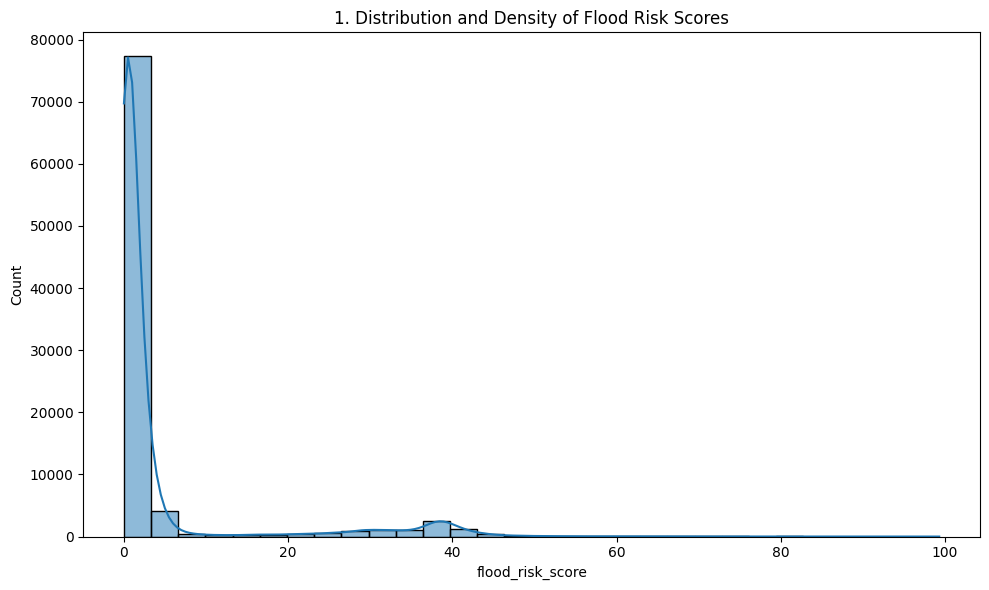

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='flood_risk_score', kde=True, bins=30)
plt.title(f'{plot_no}. Distribution and Density of Flood Risk Scores')
show_fig()
plot_no += 1

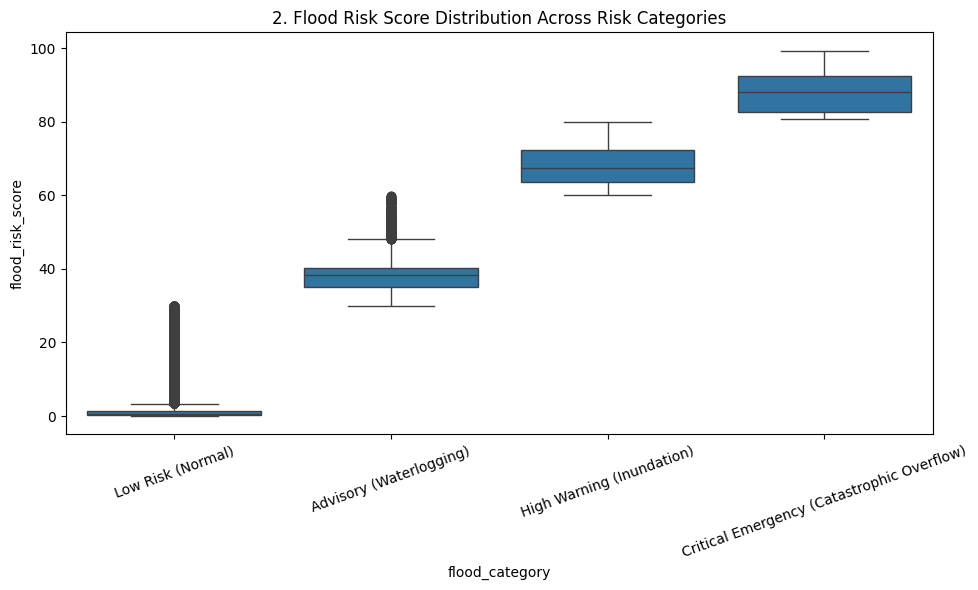

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='flood_category', y='flood_risk_score')
plt.title(f'{plot_no}. Flood Risk Score Distribution Across Risk Categories')
plt.xticks(rotation=20)
show_fig()
plot_no += 1

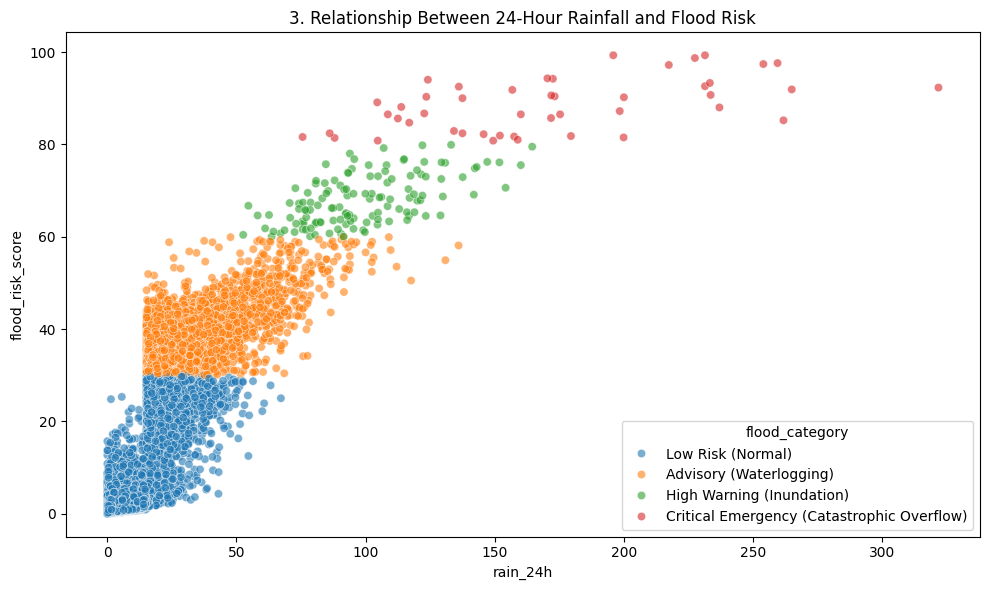

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='rain_24h', y='flood_risk_score', hue='flood_category', alpha=0.6)
plt.title(f'{plot_no}. Relationship Between 24-Hour Rainfall and Flood Risk')
show_fig()
plot_no += 1

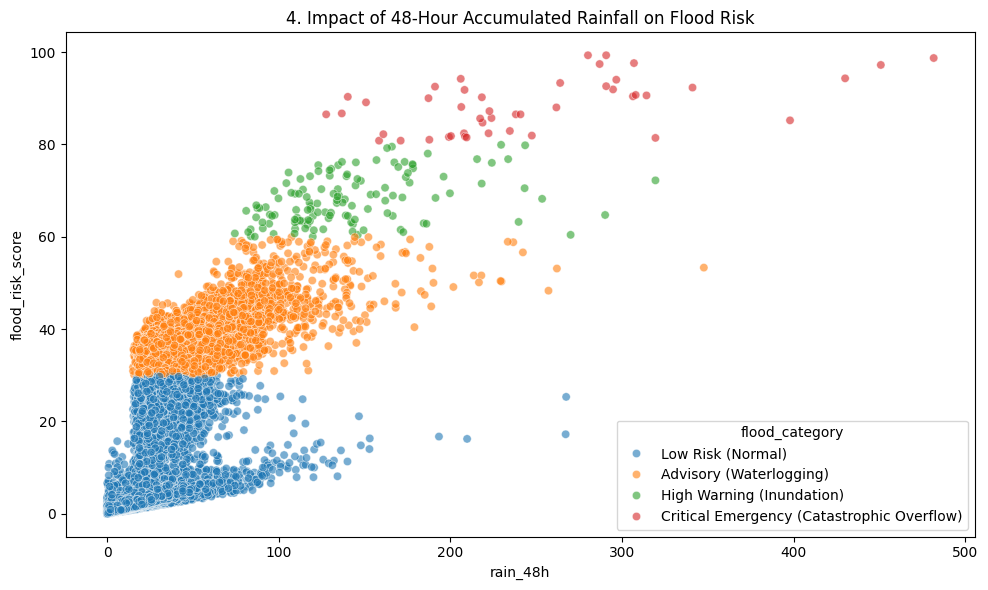

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='rain_48h', y='flood_risk_score', hue='flood_category', alpha=0.6)
plt.title(f'{plot_no}. Impact of 48-Hour Accumulated Rainfall on Flood Risk')
show_fig()
plot_no += 1

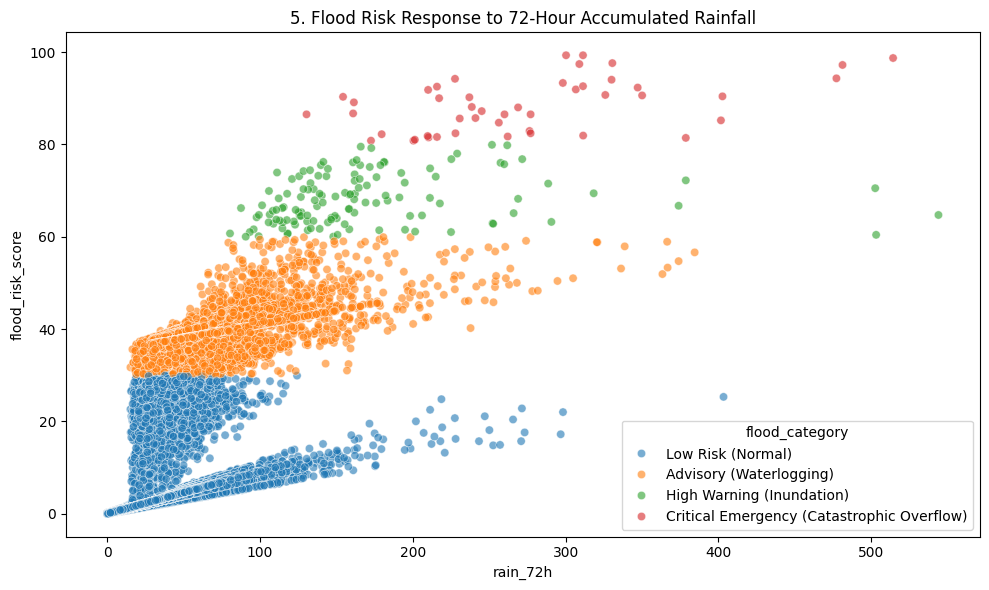

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='rain_72h', y='flood_risk_score', hue='flood_category', alpha=0.6)
plt.title(f'{plot_no}. Flood Risk Response to 72-Hour Accumulated Rainfall')
show_fig()
plot_no += 1

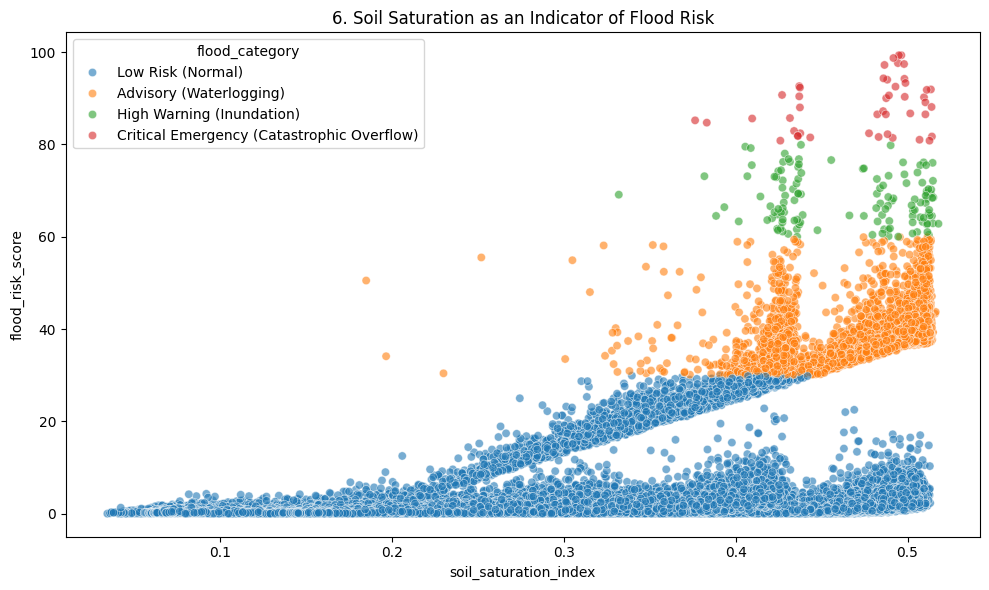

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='soil_saturation_index', y='flood_risk_score', hue='flood_category', alpha=0.6)
plt.title(f'{plot_no}. Soil Saturation as an Indicator of Flood Risk')
show_fig()
plot_no += 1

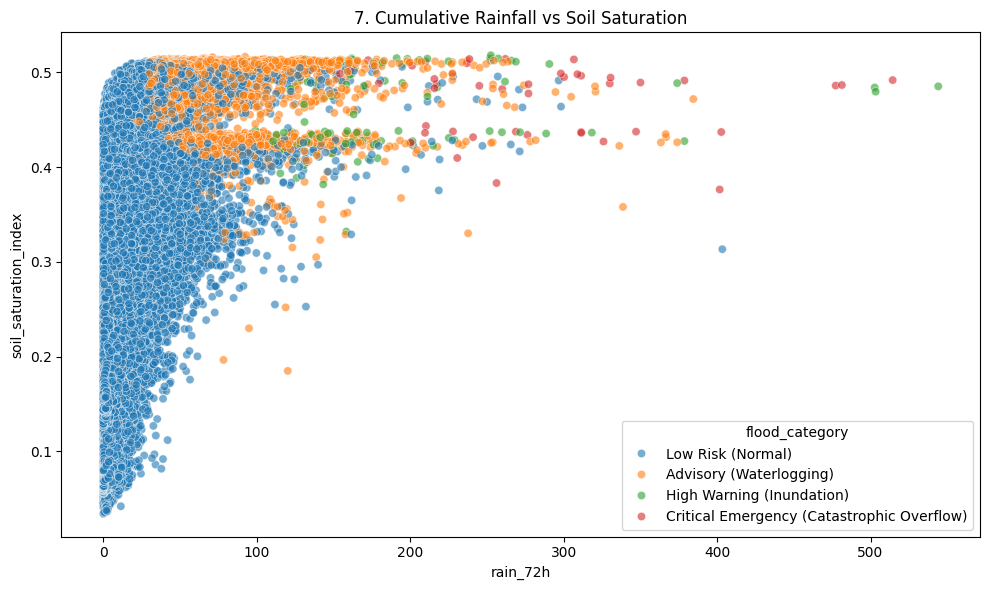

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='rain_72h', y='soil_saturation_index', hue='flood_category', alpha=0.6)
plt.title(f'{plot_no}. Cumulative Rainfall vs Soil Saturation')
show_fig()
plot_no += 1

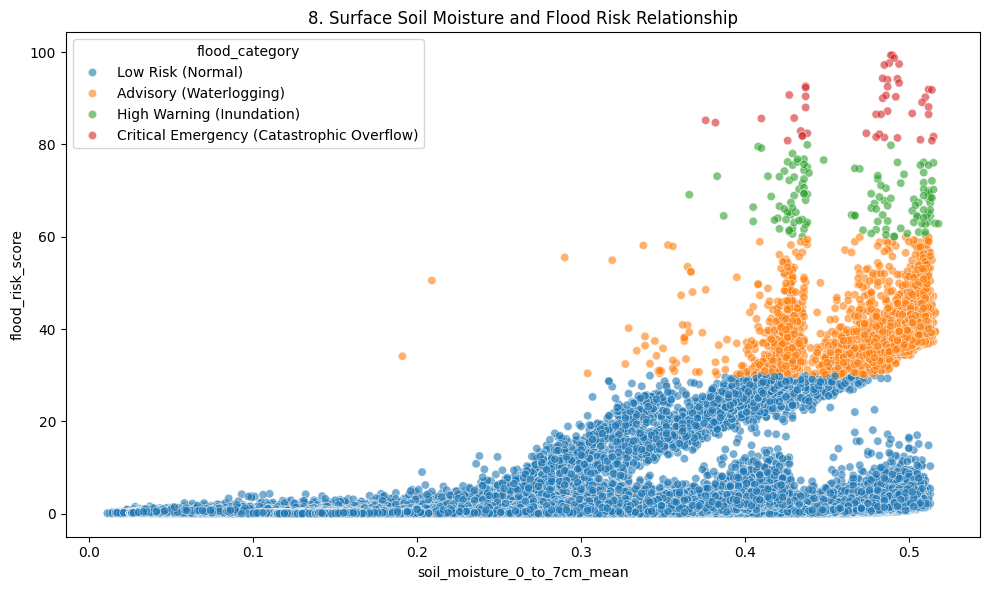

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='soil_moisture_0_to_7cm_mean', y='flood_risk_score', hue='flood_category', alpha=0.6)
plt.title(f'{plot_no}. Surface Soil Moisture and Flood Risk Relationship')
show_fig()
plot_no += 1

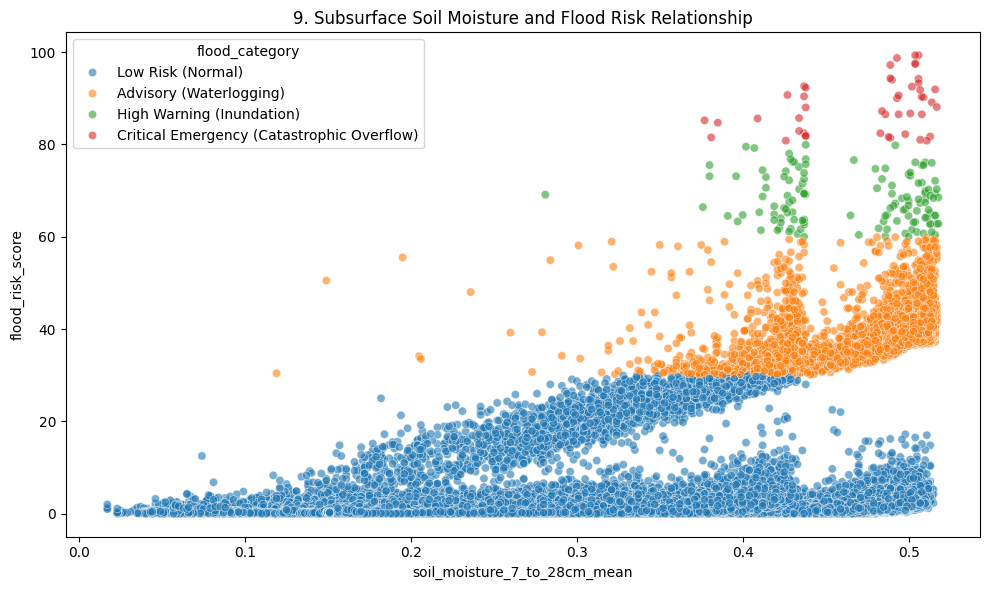

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='soil_moisture_7_to_28cm_mean', y='flood_risk_score', hue='flood_category', alpha=0.6)
plt.title(f'{plot_no}. Subsurface Soil Moisture and Flood Risk Relationship')
show_fig()
plot_no += 1

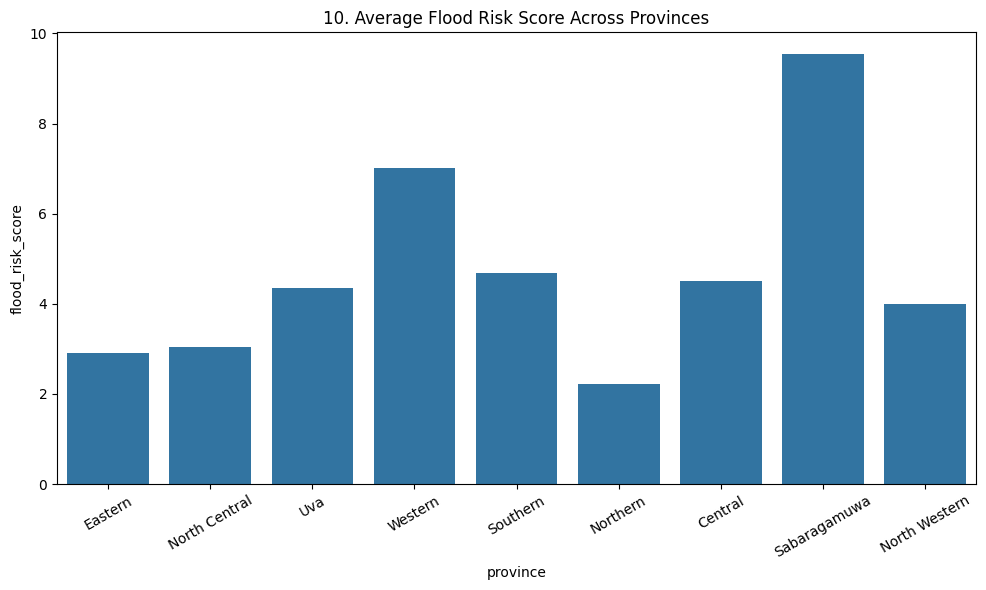

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='province', y='flood_risk_score', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Flood Risk Score Across Provinces')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

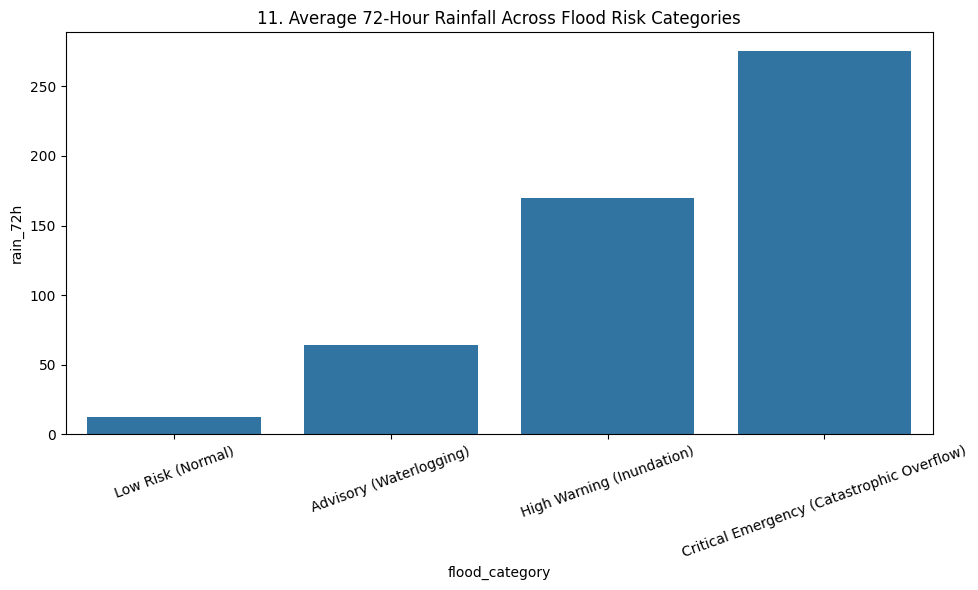

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='flood_category', y='rain_72h', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average 72-Hour Rainfall Across Flood Risk Categories')
plt.xticks(rotation=20)
show_fig()
plot_no += 1

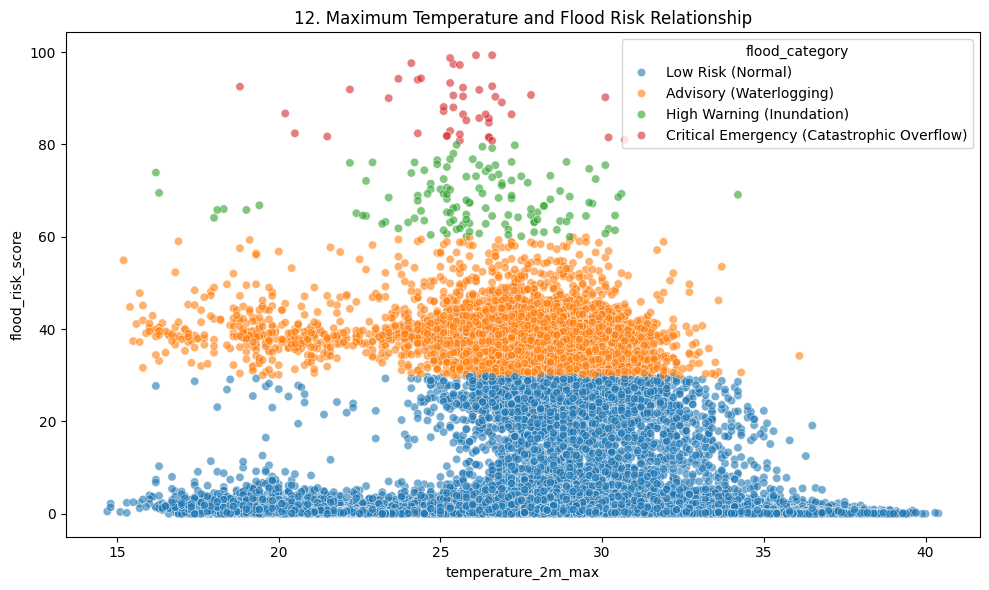

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='temperature_2m_max', y='flood_risk_score', hue='flood_category', alpha=0.6)
plt.title(f'{plot_no}. Maximum Temperature and Flood Risk Relationship')
show_fig()
plot_no += 1

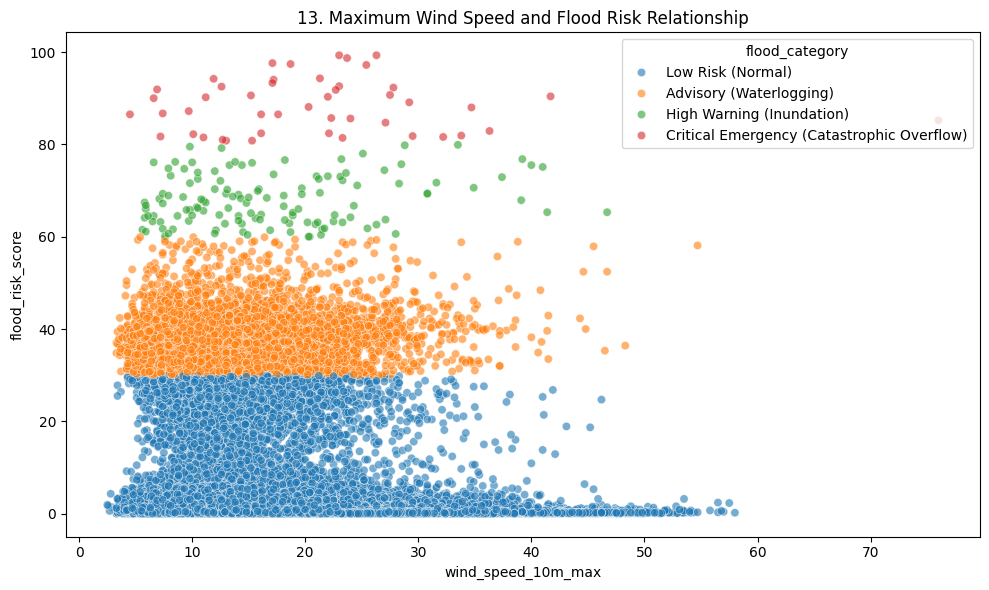

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='wind_speed_10m_max', y='flood_risk_score', hue='flood_category', alpha=0.6)
plt.title(f'{plot_no}. Maximum Wind Speed and Flood Risk Relationship')
show_fig()
plot_no += 1

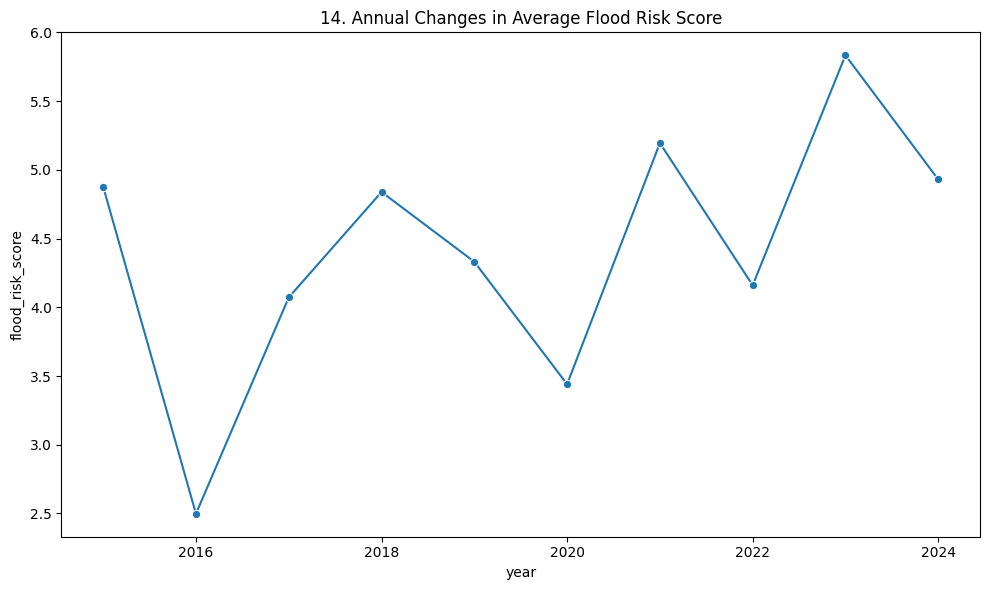

In [26]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='year', y='flood_risk_score', estimator='mean', errorbar=None, marker='o')
plt.title(f'{plot_no}. Annual Changes in Average Flood Risk Score')
show_fig()
plot_no += 1

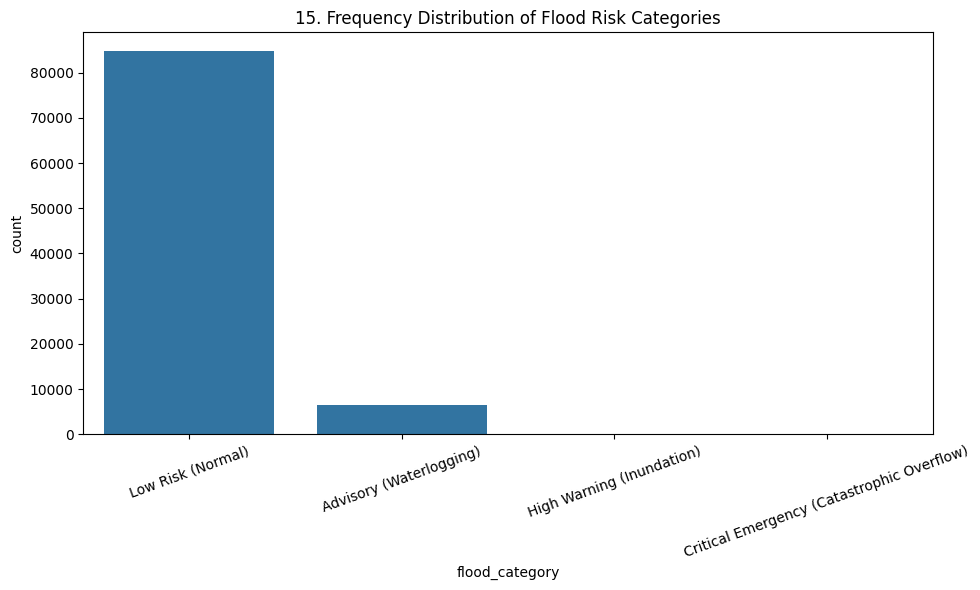

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='flood_category', order=df['flood_category'].value_counts().index)
plt.title(f'{plot_no}. Frequency Distribution of Flood Risk Categories')
plt.xticks(rotation=20)
show_fig()
plot_no += 1

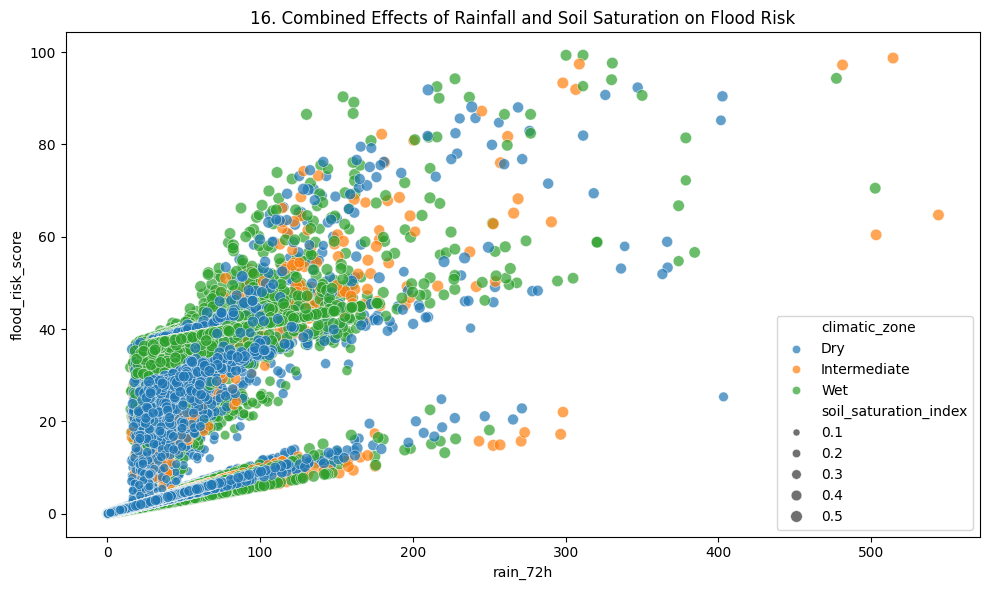

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='rain_72h', y='flood_risk_score', size='soil_saturation_index', hue='climatic_zone', alpha=0.7)
plt.title(f'{plot_no}. Combined Effects of Rainfall and Soil Saturation on Flood Risk')
show_fig()
plot_no += 1

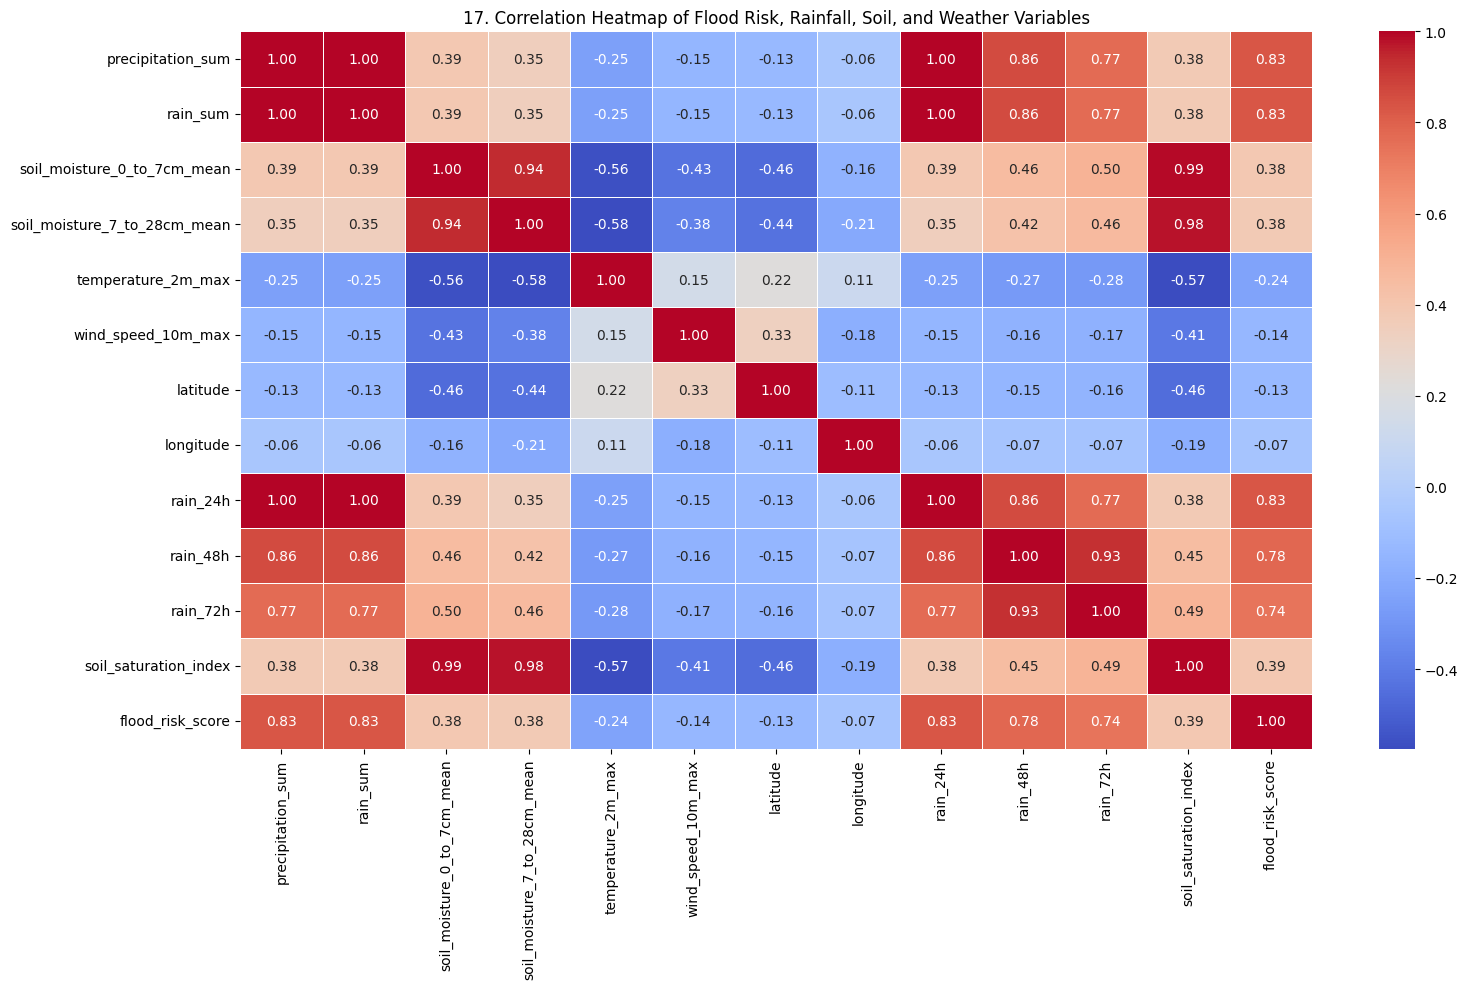

In [29]:
corr = df.select_dtypes(include='number').drop(columns=['year'], errors='ignore').corr()

fig = plt.figure(figsize=(16,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Flood Risk, Rainfall, Soil, and Weather Variables')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [30]:
X = df.drop(columns=['flood_risk_score', 'flood_category', 'date'], errors='ignore')
y = df['flood_risk_score']

## Convert categorical features into numerical format

In [31]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

## Split dataset into training and testing sets

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Handle missing values

In [33]:
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

## Train a gradient boosting regression model

In [34]:
model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

model.fit(X_train, y_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.08
,max_iter,200
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,1.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


## Generate predictions

In [35]:
y_pred = model.predict(X_test)

## Evaluate model performance

In [36]:
print("R² Score:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))

R² Score: 0.9952
MAE: 0.1132
RMSE: 0.7472


## Plot actual vs predicted flood risk scores

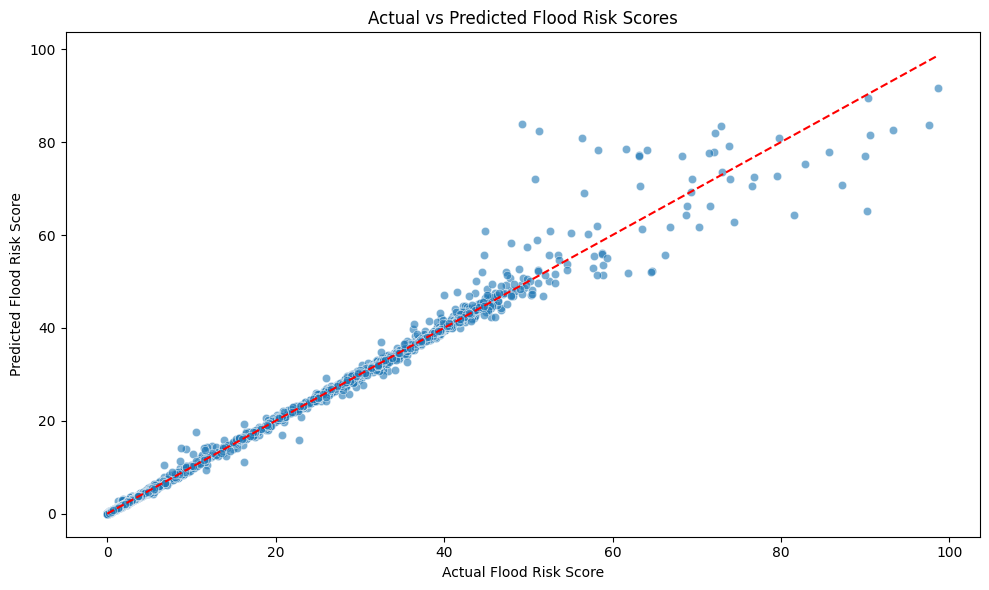

In [37]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Flood Risk Score")
plt.ylabel("Predicted Flood Risk Score")
plt.title("Actual vs Predicted Flood Risk Scores")
show_fig()